# Centro Federal de Educação Tecnológica de Minas Gerais
**Campus VIII – Varginha**  
**Bacharelado em Sistemas de Informação**  
**Disciplina:** Lab. Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  
**Aluno(a):** Álvaro Henrique Duarte Mendes  

---

# Atividade 09 - Agrupamento com Rede de Kohonen (SOM)

Este notebook apresenta a implementação e a simulação de uma Rede de Kohonen (Self-Organizing Map - SOM) com uma estrutura de grid bidimensional 4x4 (16 neurônios ocultos) e 3 entradas. O objetivo é agrupar amostras de composto de borracha para fabricação de pneus em 3 classes distintas (Classes A, B e C).

### 1. Importações e Configuração de Caminhos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionar o diretório atual ao sys.path para importar solve_kohonen
sys.path.append(os.getcwd())
from solve_kohonen import KohonenSOM, get_neuron_class_mapping, print_grid_map

### 2. Carregamento dos Dados

- **Dados de Treinamento**: 120 amostras do apêndice. Os engenheiros rotularam as classes a posteriori:
  - Amostras 1 a 20: Classe A (20 amostras)
  - Amostras 21 a 60: Classe B (40 amostras)
  - Amostras 61 a 120: Classe C (60 amostras)
- **Dados de Validação**: 12 amostras a serem classificadas.

In [2]:
TRAINING_DATA = [[0.2417, 0.2857, 0.2397], [0.2268, 0.2874, 0.2153], [0.1975, 0.3315, 0.1965], [0.3414, 0.3166, 0.1074], [0.2587, 0.1918, 0.2634], [0.2455, 0.2075, 0.1344], [0.3163, 0.1679, 0.1725], [0.2704, 0.2605, 0.1411], [0.1871, 0.2965, 0.1231], [0.3474, 0.2715, 0.1958], [0.2059, 0.2928, 0.2839], [0.2442, 0.2272, 0.2384], [0.2126, 0.3437, 0.1128], [0.2562, 0.2542, 0.1599], [0.164, 0.2289, 0.2627], [0.2795, 0.188, 0.1627], [0.3463, 0.1513, 0.2281], [0.343, 0.1508, 0.1881], [0.1981, 0.2821, 0.1294], [0.2322, 0.3025, 0.2191], [0.7352, 0.2722, 0.6962], [0.7191, 0.1825, 0.747], [0.6921, 0.1537, 0.8172], [0.6833, 0.2048, 0.849], [0.8012, 0.2684, 0.7673], [0.786, 0.1734, 0.7198], [0.7205, 0.1542, 0.7295], [0.6549, 0.3288, 0.8153], [0.6968, 0.3173, 0.7389], [0.7448, 0.2095, 0.6847], [0.6746, 0.3277, 0.6725], [0.7897, 0.2801, 0.7679], [0.8399, 0.3067, 0.7003], [0.8065, 0.3206, 0.7205], [0.8357, 0.322, 0.7879], [0.7438, 0.323, 0.8384], [0.8172, 0.3319, 0.7628], [0.8248, 0.2614, 0.8405], [0.6979, 0.2142, 0.7309], [0.6804, 0.3181, 0.7017], [0.6973, 0.3194, 0.7522], [0.791, 0.2239, 0.7018], [0.7052, 0.2148, 0.6866], [0.8088, 0.1908, 0.7563], [0.764, 0.1676, 0.6994], [0.7616, 0.2881, 0.8087], [0.8188, 0.2461, 0.7273], [0.792, 0.3178, 0.7497], [0.7802, 0.1871, 0.8102], [0.7332, 0.2543, 0.8194], [0.6921, 0.1529, 0.7759], [0.6833, 0.2197, 0.6943], [0.786, 0.1745, 0.7639], [0.8009, 0.3082, 0.8491], [0.7793, 0.1935, 0.6738], [0.7373, 0.2698, 0.7864], [0.7048, 0.238, 0.7825], [0.8393, 0.2857, 0.7733], [0.6878, 0.2126, 0.6961], [0.6651, 0.3492, 0.6737], [0.4856, 0.66, 0.4798], [0.4114, 0.722, 0.5106], [0.5671, 0.7935, 0.5929], [0.4875, 0.7928, 0.5532], [0.5172, 0.7147, 0.5774], [0.5483, 0.6773, 0.4842], [0.574, 0.6682, 0.5335], [0.4587, 0.6981, 0.59], [0.5794, 0.741, 0.4759], [0.4712, 0.6734, 0.5677], [0.5126, 0.8141, 0.5224], [0.5557, 0.7749, 0.4342], [0.4916, 0.8267, 0.4586], [0.4629, 0.8129, 0.495], [0.585, 0.7358, 0.5107], [0.4435, 0.703, 0.4594], [0.4155, 0.7516, 0.5524], [0.4887, 0.7027, 0.5886], [0.5462, 0.7378, 0.5107], [0.5251, 0.8124, 0.5686], [0.4635, 0.7339, 0.5638], [0.5907, 0.7144, 0.4718], [0.4982, 0.8335, 0.4597], [0.5242, 0.7325, 0.4079], [0.4075, 0.8372, 0.4271], [0.5934, 0.8284, 0.5107], [0.5463, 0.6766, 0.5639], [0.4403, 0.8495, 0.4806], [0.4531, 0.776, 0.5276], [0.5109, 0.7387, 0.5373], [0.5383, 0.778, 0.4955], [0.5679, 0.7156, 0.5022], [0.5762, 0.7781, 0.5908], [0.5997, 0.7504, 0.5678], [0.4138, 0.6975, 0.5148], [0.549, 0.6674, 0.4472], [0.4719, 0.7527, 0.4401], [0.4458, 0.8063, 0.4253], [0.4983, 0.8131, 0.5625], [0.5742, 0.6789, 0.5997], [0.5289, 0.7354, 0.4718], [0.5927, 0.7738, 0.539], [0.5199, 0.7131, 0.4028], [0.5716, 0.6558, 0.4451], [0.5075, 0.7045, 0.4233], [0.4886, 0.7004, 0.4608], [0.5527, 0.8243, 0.5772], [0.4816, 0.6969, 0.4678], [0.5809, 0.6557, 0.4266], [0.5881, 0.7565, 0.4003], [0.5334, 0.8446, 0.4934], [0.4603, 0.7992, 0.4816], [0.5491, 0.6504, 0.4063], [0.4288, 0.8455, 0.5047], [0.5636, 0.7884, 0.5417], [0.5349, 0.6736, 0.4541], [0.5569, 0.8393, 0.5652], [0.4729, 0.7702, 0.5325], [0.5472, 0.8454, 0.5449], [0.5805, 0.7349, 0.4464]]
VALIDATION_DATA = [[0.2471, 0.1778, 0.2905], [0.824, 0.2223, 0.7041], [0.496, 0.7231, 0.5866], [0.2923, 0.2041, 0.2234], [0.8118, 0.2668, 0.7484], [0.4837, 0.82, 0.4792], [0.3248, 0.2629, 0.2375], [0.7209, 0.2116, 0.7821], [0.5259, 0.6522, 0.5957], [0.2075, 0.1669, 0.1745], [0.783, 0.3171, 0.7888], [0.5393, 0.751, 0.5682]]

print(f"Total de amostras de treinamento: {len(TRAINING_DATA)}")
print(f"Total de amostras de validação: {len(VALIDATION_DATA)}")

Total de amostras de treinamento: 120
Total de amostras de validação: 12


### 3. Treinamento da Rede de Kohonen (SOM)

Instanciamos um SOM com estrutura 4x4, raio de vizinhança = 1, taxa de aprendizado = 0.001 e treinamos por 5000 épocas para garantir convergência estável.

In [3]:
som = KohonenSOM(grid_shape=(4, 4), input_dim=3, learning_rate=0.001, radius=1)
som.train(TRAINING_DATA, epochs=5000, shuffle=True, seed=42)

print("Rede de Kohonen treinada com sucesso!")

Rede de Kohonen treinada com sucesso!


### 4. Mapeamento de Classes e Visualização do Grid Topológico

Apresentamos os dados à rede, registramos os vencedores e mapeamos o rótulo de cada neurônio.

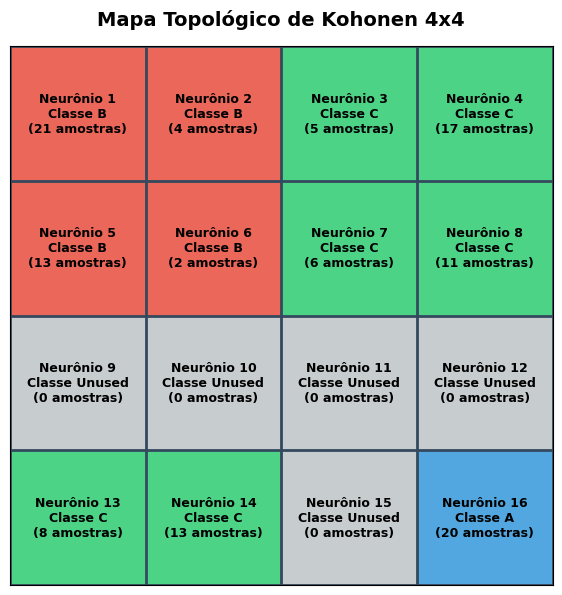

In [4]:
mapping = get_neuron_class_mapping(som, TRAINING_DATA)

# Desenhar mapa topológico 2D
fig, ax = plt.subplots(figsize=(7, 7))
for i in range(5):
    ax.axhline(i, color='#34495e', lw=2)
    ax.axvline(i, color='#34495e', lw=2)

colors = {'A': '#3498db', 'B': '#e74c3c', 'C': '#2ecc71', 'Unused': '#bdc3c7'}
for r in range(4):
    for c in range(4):
        neuron_idx = r * 4 + c
        cls, wins, dist = mapping[neuron_idx]
        color = colors[cls]
        rect = plt.Rectangle((c, 3-r), 1, 1, facecolor=color, edgecolor='none', alpha=0.85)
        ax.add_patch(rect)
        ax.text(c + 0.5, 3-r + 0.5, f"Neurônio {neuron_idx+1}\nClasse {cls}\n({wins} amostras)",
                 color='black', ha='center', va='center', weight='bold', fontsize=9)

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mapa Topológico de Kohonen 4x4', fontsize=14, weight='bold', pad=15)
plt.savefig('mapa_topologico.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Dispersão 3D dos Dados e Pesos

Visualizamos a distribuição 3D das amostras e como os pesos dos neurônios (grid de triângulos pretos) se auto-organizam.

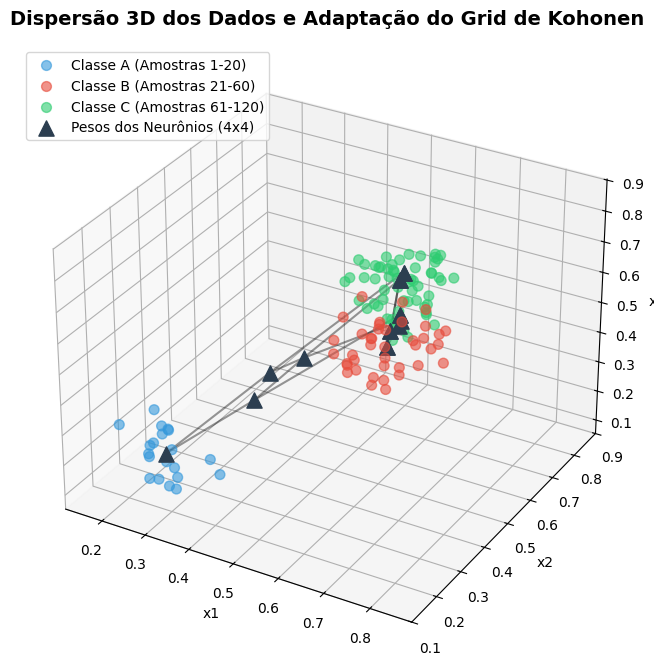

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X = np.array(TRAINING_DATA)
ax.scatter(X[:20, 0], X[:20, 1], X[:20, 2], c='#3498db', label='Classe A (Amostras 1-20)', s=50, alpha=0.6)
ax.scatter(X[20:60, 0], X[20:60, 1], X[20:60, 2], c='#e74c3c', label='Classe B (Amostras 21-60)', s=50, alpha=0.6)
ax.scatter(X[60:, 0], X[60:, 1], X[60:, 2], c='#2ecc71', label='Classe C (Amostras 61-120)', s=50, alpha=0.6)

W = som.W
ax.scatter(W[:, 0], W[:, 1], W[:, 2], c='#2c3e50', marker='^', s=120, label='Pesos dos Neurônios (4x4)', depthshade=False)

# Conectar vizinhos topológicos do grid 4x4
for r in range(4):
    for c in range(4):
        curr_idx = r * 4 + c
        if c < 3:
            right_idx = r * 4 + (c + 1)
            ax.plot([W[curr_idx, 0], W[right_idx, 0]],
                    [W[curr_idx, 1], W[right_idx, 1]],
                    [W[curr_idx, 2], W[right_idx, 2]], color='black', alpha=0.4, lw=1.5)
        if r < 3:
            bottom_idx = (r + 1) * 4 + c
            ax.plot([W[curr_idx, 0], W[bottom_idx, 0]],
                    [W[curr_idx, 1], W[bottom_idx, 1]],
                    [W[curr_idx, 2], W[bottom_idx, 2]], color='black', alpha=0.4, lw=1.5)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Dispersão 3D dos Dados e Adaptação do Grid de Kohonen', fontsize=14, weight='bold', pad=15)
ax.legend(loc='upper left')
plt.savefig('dispersao_3d.png', dpi=300, bbox_inches='tight')
plt.show()

### 6. Classificação das Amostras de Teste/Validação

In [6]:
print("Classificação das 12 Amostras de Validação:")
print("-" * 70)
print(f"{'Amostra':<10} | {'x1':<8} | {'x2':<8} | {'x3':<8} | {'Neurônio Vencedor':<17} | {'Classe atribuída'}")
print("-" * 70)
for idx, x in enumerate(VALIDATION_DATA):
    winner = som.get_winner(x)
    cls, _, _ = mapping[winner]
    print(f"{idx+1:<10d} | {x[0]:<8.4f} | {x[1]:<8.4f} | {x[2]:<8.4f} | {winner+1:<17d} | Class {cls}")

Classificação das 12 Amostras de Validação:
----------------------------------------------------------------------
Amostra    | x1       | x2       | x3       | Neurônio Vencedor | Classe atribuída
----------------------------------------------------------------------
1          | 0.2471   | 0.1778   | 0.2905   | 16                | Class A
2          | 0.8240   | 0.2223   | 0.7041   | 1                 | Class B
3          | 0.4960   | 0.7231   | 0.5866   | 3                 | Class C
4          | 0.2923   | 0.2041   | 0.2234   | 16                | Class A
5          | 0.8118   | 0.2668   | 0.7484   | 1                 | Class B
6          | 0.4837   | 0.8200   | 0.4792   | 4                 | Class C
7          | 0.3248   | 0.2629   | 0.2375   | 16                | Class A
8          | 0.7209   | 0.2116   | 0.7821   | 1                 | Class B
9          | 0.5259   | 0.6522   | 0.5957   | 7                 | Class C
10         | 0.2075   | 0.1669   | 0.1745   | 16                |